# Password Strength Evaluation — RNN (LSTM) Classifier

- `0` → Weak
- `1` → Moderate  
- `2` → Strong

## 1. Install & Import Dependencies

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')
if device.type == 'cuda':
    print(f'GPU name     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA version : {torch.version.cuda}')


Using device : cuda
GPU name     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM         : 4.3 GB
CUDA version : 13.2


In [3]:
# Dataset columns
PASSWORD_COL  = 'password'
STRENGTH_COL  = 'strength'

MAX_LEN       = 30       

EMBED_DIM     = 64       # character embedding size
HIDDEN_DIM    = 128      
NUM_LAYERS    = 2        # stacked LSTM layers
DROPOUT       = 0.3
NUM_CLASSES   = 3        

BATCH_SIZE    = 512      
EPOCHS        = 10
LEARNING_RATE = 1e-3
TEST_SIZE     = 0.3

LABEL_NAMES   = ['Weak', 'Moderate', 'Strong']
print('Config loaded')

Config loaded


## 3. Load & Explore the Dataset

In [4]:
df = pd.read_csv('password.csv')

# Drop nulls and ensure correct types
df = df[[PASSWORD_COL, STRENGTH_COL]].dropna()
df[PASSWORD_COL] = df[PASSWORD_COL].astype(str)
df[STRENGTH_COL] = df[STRENGTH_COL].astype(int)

print(f'Dataset shape : {df.shape}')
print(f'\nClass distribution:')
for label, name in enumerate(LABEL_NAMES):
    count = (df[STRENGTH_COL] == label).sum()
    print(f'  {name:10s} ({label}): {count:,}  ({count/len(df)*100:.1f}%)')
df.head()

Dataset shape : (100000, 2)

Class distribution:
  Weak       (0): 13,557  (13.6%)
  Moderate   (1): 74,111  (74.1%)
  Strong     (2): 12,332  (12.3%)


,password,strength
0,yrtzuab476,1
1,yEdnN9jc1NgzkkBP,2
2,sarita99,1
3,Suramerica2015,2
4,PPRbMvDIxMQ19TMo,2


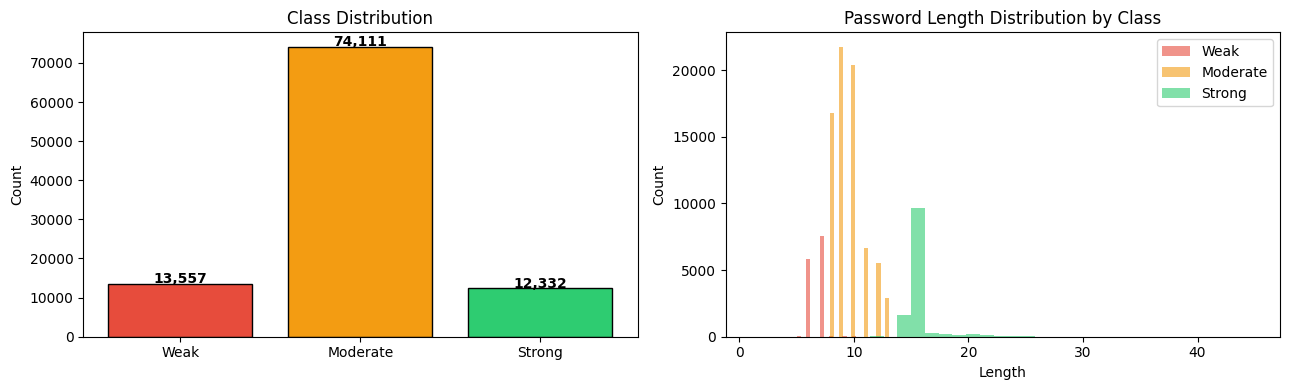


Password length stats:
count    100000.000000
mean          9.975570
std           2.766675
min           1.000000
25%           8.000000
50%           9.000000
75%          11.000000
max          45.000000
Name: pw_len, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df[STRENGTH_COL].value_counts().sort_index()
axes[0].bar(LABEL_NAMES, counts.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Password length by class
df['pw_len'] = df[PASSWORD_COL].str.len()
for label, name, color in zip([0,1,2], LABEL_NAMES, ['#e74c3c','#f39c12','#2ecc71']):
    subset = df[df[STRENGTH_COL] == label]['pw_len']
    axes[1].hist(subset, bins=30, alpha=0.6, label=name, color=color)
axes[1].set_title('Password Length Distribution by Class')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'\nPassword length stats:\n{df["pw_len"].describe()}')

## 4. Character-Level Tokenisation

In [6]:
# Build vocabulary from all unique characters in the dataset
all_chars = set(''.join(df[PASSWORD_COL].tolist()))
all_chars = sorted(all_chars)

# Reserve index 0 for padding
char2idx = {ch: idx + 1 for idx, ch in enumerate(all_chars)}
char2idx['<PAD>'] = 0

VOCAB_SIZE = len(char2idx)
print(f'Vocabulary size : {VOCAB_SIZE} unique characters')

sample_mappings = {
    "+": char2idx.get("+", "N/A"),
    "a": char2idx.get("a", "N/A"),
    "A": char2idx.get("A", "N/A")
}

print(f'Sample mappings : {sample_mappings}')


def encode_password(pw: str, max_len: int = MAX_LEN) -> list:
    """Convert a password string to a fixed-length integer sequence."""
    encoded = [char2idx.get(ch, 0) for ch in pw[:max_len]]
    # Pad with zeros to max_len
    padded  = encoded + [0] * (max_len - len(encoded))
    return padded

# Quick test
sample = 'P@ssw0rd!'
print(f'\nSample encoding of "{sample}":')
print(encode_password(sample))

Vocabulary size : 113 unique characters
Sample mappings : {'+': 12, 'a': 63, 'A': 32}

Sample encoding of "P@ssw0rd!":
[47, 31, 81, 81, 85, 16, 80, 66, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. PyTorch Dataset & DataLoaders

In [7]:
class PasswordDataset(Dataset):
    def __init__(self, passwords, labels):
        self.X = torch.tensor(
            [encode_password(pw) for pw in passwords], dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    df[PASSWORD_COL].values,
    df[STRENGTH_COL].values,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=df[STRENGTH_COL].values
)

train_ds = PasswordDataset(X_train, y_train)
test_ds  = PasswordDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Train samples : {len(train_ds):,}')
print(f'Test  samples : {len(test_ds):,}')
print(f'Batches/epoch : {len(train_loader)}')

Train samples : 70,000
Test  samples : 30,000
Batches/epoch : 137


## 6. Define the LSTM/RNN Model

In [8]:
class PasswordRNN(nn.Module):
    """
    Character-level Bidirectional LSTM for password strength classification.

    Architecture:
      Embedding  →  BiLSTM (stacked)  →  Dropout  →  FC  →  Softmax
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True       # forward + backward pass
        )

        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)   # *2 for bidirectional

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)                   # (batch, seq_len, embed_dim)
        out, (hidden, _) = self.lstm(emb)         # out: (batch, seq_len, hidden*2)

        # Concatenate last forward & backward hidden states
        fwd = hidden[-2]   # last layer, forward
        bwd = hidden[-1]   # last layer, backward
        combined = torch.cat([fwd, bwd], dim=1)   # (batch, hidden*2)

        combined = self.layer_norm(combined)
        combined = self.dropout(combined)
        return self.fc(combined)                  # (batch, num_classes)


model = PasswordRNN(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

PasswordRNN(
  (embedding): Embedding(113, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)

Total trainable parameters: 634,947


## 7. Loss Function, Optimizer & Scheduler

In [9]:
# Compute class weights to handle imbalance
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (NUM_CLASSES * class_counts),
    dtype=torch.float
).to(device)
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Reduce LR by 0.5 if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print('Loss / optimizer / scheduler ready!')

Class weights: [2.459 0.45  2.703]
Loss / optimizer / scheduler ready!


## 8. Training Loop

In [10]:
def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.no_grad() if not training else torch.enable_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


# ── Main training loop ────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

print(f'Training on {device} for {EPOCHS} epochs…\n')
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>10}  {"Val Acc":>10}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(test_loader,  training=False)

    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Save best model checkpoint
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_password_rnn.pt')
        flag = ' ← best'
    else:
        flag = ''

    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>9.2f}%  {vl_loss:>10.4f}  {vl_acc*100:>9.2f}%{flag}')

print('\nTraining complete')

Training on cuda for 10 epochs…

 Epoch  Train Loss   Train Acc    Val Loss     Val Acc
-------------------------------------------------------
     1      0.3584      82.16%      0.0466      98.91% ← best
     2      0.0437      98.82%      0.0287      99.51% ← best
     3      0.0341      99.24%      0.0281      99.62% ← best
     4      0.0281      99.52%      0.0314      98.95%
     5      0.0279      99.47%      0.0308      99.45%
     6      0.0255      99.54%      0.0224      99.68% ← best
     7      0.0232      99.59%      0.0285      99.65%
     8      0.0214      99.63%      0.0238      99.63%
     9      0.0221      99.61%      0.0238      99.71%
    10      0.0204      99.66%      0.0210      99.72% ← best

Training complete


## 9. Training Curves

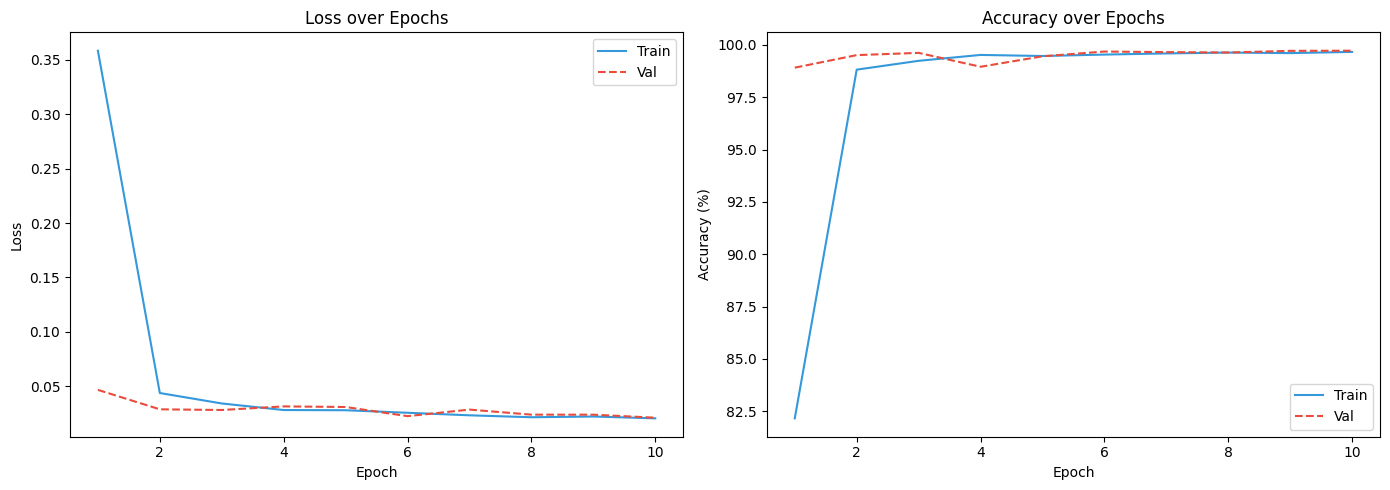

In [11]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#3498db')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#e74c3c', linestyle='--')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='#3498db')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='#e74c3c', linestyle='--')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Evaluation on Test Set

In [12]:
# Load the best checkpoint
model.load_state_dict(torch.load('best_password_rnn.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f'Test Accuracy : {accuracy_score(all_labels, all_preds)*100:.2f}%\n')
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

Test Accuracy : 99.72%

Classification Report:
              precision    recall  f1-score   support

        Weak       1.00      0.99      0.99      4067
    Moderate       1.00      1.00      1.00     22233
      Strong       0.99      1.00      0.99      3700

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



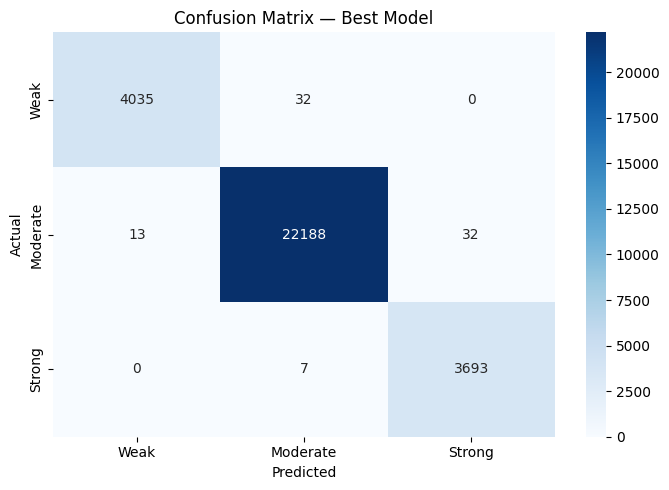

In [13]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('Confusion Matrix — Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Predict on New Passwords

In [16]:
STRENGTH_ICON = {0: 'Weak', 1: 'Moderate', 2: 'Strong'}

def predict_password(password: str) -> dict:
    """Evaluate the strength of a single password."""
    model.eval()
    encoded = torch.tensor([encode_password(password)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(encoded)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        label  = int(np.argmax(probs))
    return {
        'password'   : password,
        'strength'   : STRENGTH_ICON[label],
        'weak_%'     : f'{probs[0]*100:.1f}',
        'moderate_%' : f'{probs[1]*100:.1f}',
        'strong_%'   : f'{probs[2]*100:.1f}',
    }


test_passwords = [
    '123456',
    'password',
    'Hello123',
    'P@ssw0rd!',
    'Ji7Bp)T(ZfVh',
    'l7Gm$#0zCF6#',
    'PZ}fl*>dLR7ef',
    'pN_EMwCaOvA?5G',
    'S*koB^TlApyq8P!',
]

results = pd.DataFrame([predict_password(pw) for pw in test_passwords])
print(results.to_string(index=False))

       password strength weak_% moderate_% strong_%
         123456     Weak  100.0        0.0      0.0
       password     Weak   50.5       48.7      0.8
       Hello123 Moderate    0.5       99.5      0.0
      P@ssw0rd! Moderate   42.6       45.5     11.9
   Ji7Bp)T(ZfVh   Strong    0.0        1.0     99.0
   l7Gm$#0zCF6#   Strong    0.0        2.7     97.3
  PZ}fl*>dLR7ef   Strong    0.0        0.0    100.0
 pN_EMwCaOvA?5G   Strong    0.0        0.0    100.0
S*koB^TlApyq8P!   Strong    0.0        0.0    100.0


### 12. Save Full Model & Vocabulary

In [15]:
import json

# Save vocabulary mapping (needed for inference)
with open('char2idx.json', 'w') as f:
    json.dump(char2idx, f)

# Save full model state
torch.save({
    'model_state_dict' : model.state_dict(),
    'char2idx'         : char2idx,
    'config': {
        'vocab_size'  : VOCAB_SIZE,
        'embed_dim'   : EMBED_DIM,
        'hidden_dim'  : HIDDEN_DIM,
        'num_layers'  : NUM_LAYERS,
        'num_classes' : NUM_CLASSES,
        'dropout'     : DROPOUT,
        'max_len'     : MAX_LEN,
    }
}, 'password_rnn_full.pt')

print('Saved:')
print('  password_rnn_full.pt  — full model + config')
print('  char2idx.json         — character vocabulary')
print('  best_password_rnn.pt  — best checkpoint (lowest val loss)')

Saved:
  password_rnn_full.pt  — full model + config
  char2idx.json         — character vocabulary
  best_password_rnn.pt  — best checkpoint (lowest val loss)
